# AdaBoost

### Fixing mistakes by making them heavier

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | Why boosting is sequential where bagging is parallel, where the vote $\alpha$ given to each weak learner comes from, why AdaBoost is gradient boosting wearing a different hat, why the base learner should be weak on purpose, and why a handful of wrong labels wrecks it |
| **You should already know** | [Bagging](../01-bagging/), [decision trees](../../03-classification/06-decision-trees/) |
| **Dataset** | UCI Dry Bean, restricted to the two largest varieties so the problem is binary |
| **Runtime** | Two to three minutes on a laptop CPU |
| **Next** | [04-05 Gradient boosting](../05-gradient-boosting/) |

---

## 1. The idea

[Bagging](../01-bagging/) trains its models **in parallel**. Each one sees its own
bootstrap sample, none of them knows the others exist, and the ensemble is their
average. Nothing coordinates them, which is the point: their mistakes are supposed
to be independent so that averaging cancels them.

AdaBoost trains its models **in sequence**, and every model after the first is
built with full knowledge of what went wrong before it. The loop is short:

1. Give every training row the same weight.
2. Fit a weak model on the weighted data.
3. Multiply the weight of every row it got wrong, divide the weight of every row
   it got right.
4. Repeat. At the end, let the models vote, each with a vote size $\alpha$ that
   depends on how accurate it was.

So the data never changes. Only its weights change, and a row that keeps being
missed keeps getting heavier until some weak model finally has to pay attention
to it.

### Three ensembles, side by side

| | Bagging | AdaBoost | Gradient boosting |
|---|---|---|---|
| **Order** | Parallel, any order | Sequential | Sequential |
| **What each new model sees** | A fresh bootstrap sample | The same rows, reweighted | The same rows, with the residual as the new target |
| **Combined by** | Plain average | Weighted vote, $\alpha$ per model | Sum of shrunken corrections |
| **Mainly reduces** | Variance | Bias | Bias |
| **Wants base models that are** | Too strong | Too weak | Too weak |

The last row surprises people. Bagging wants deep unpruned trees, because it has
variance to cancel and no way to remove bias. Boosting wants the opposite, and
section 4 measures what happens when you ignore that.

The middle column and the right column look like two different algorithms.
Section 2 shows they are the same algorithm: **reweighting a row and fitting its
residual are the same operation, once you name the loss function.** AdaBoost is
gradient boosting with exponential loss.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

## 2. The algorithm and where alpha comes from

Label the classes $y \in \{-1, +1\}$ rather than $\{0, 1\}$. That choice does all
the work, because $y_i F(x_i)$ is then positive when the prediction $F$ is right
and negative when it is wrong, and its size says how confident the model was. That
quantity is called the **margin**.

The ensemble is an additive model,

$$F_M(x) = \sum_{m=1}^{M} \alpha_m h_m(x), \qquad h_m(x) \in \{-1, +1\},$$

and the prediction is $\operatorname{sign} F_M(x)$. AdaBoost builds it greedily:
at round $m$ it keeps $F_{m-1}$ frozen and picks the single best $(\alpha, h)$ to
add. The loss it minimises is the **exponential loss**

$$L(F) = \sum_i \exp(-y_i F(x_i)).$$

### Where the sample weights come from

Substitute $F_m = F_{m-1} + \alpha h$ and the exponential splits into a product:

$$L = \sum_i \exp\!\big(-y_i F_{m-1}(x_i)\big)\,\exp\!\big(-\alpha\, y_i h(x_i)\big)
    = \sum_i w_i \exp\!\big(-\alpha\, y_i h(x_i)\big).$$

The first factor does not involve $\alpha$ or $h$ at all, so at round $m$ it is
just a number attached to row $i$. **That number is the sample weight.** Nobody
invented the reweighting rule; it is what is left of the loss once the frozen part
is factored out. A row the ensemble already gets right has a large positive
$y_i F_{m-1}(x_i)$, so its weight is small, and a row the ensemble keeps missing
has a large negative margin, so its weight is large.

### Where alpha comes from

Since $h$ only ever returns $-1$ or $+1$, split the sum into the rows $h$ gets
right and the rows it gets wrong. With the weights normalised to sum to one, and
writing $e$ for the weighted error rate,

$$L = e^{-\alpha}(1 - e) + e^{\alpha} e.$$

Differentiate and set to zero:

$$\frac{\partial L}{\partial \alpha} = -e^{-\alpha}(1-e) + e^{\alpha} e = 0
  \;\Longrightarrow\; e^{2\alpha} = \frac{1-e}{e}
  \;\Longrightarrow\; \alpha = \tfrac{1}{2}\ln\frac{1-e}{e}.$$

A weak learner with a weighted error near zero gets an enormous vote. One at $0.5$
gets a vote of exactly zero, which is right, since a coin flip carries no
information. One that is *worse* than a coin flip gets a negative vote, which
means it is used backwards, and that is also right.

Notice what this derivation did **not** need: any assumption at all about $h$. The
same two lines also tell you how to pick $h$, because for a fixed $\alpha > 0$ the
expression above falls as $e$ falls. **Fit the weak learner to minimise weighted
error.** That is the whole instruction.

### SAMME, and the factor of two

The version in scikit-learn is SAMME, which generalises to $K$ classes:

$$\alpha_m = \ln\frac{1 - e_m}{e_m} + \ln(K - 1), \qquad
  w_i \leftarrow w_i \exp\!\big(\alpha_m \,\mathbb{1}[h_m(x_i) \neq y_i]\big).$$

For $K = 2$ the $\ln(K-1)$ term vanishes and this is exactly twice the $\alpha$
derived above. The difference changes nothing. Doubling every $\alpha$ scales $F$
by two and leaves $\operatorname{sign} F$ alone, and the weight update differs by
a constant factor that the normalisation removes. I use the SAMME form below
so my numbers line up with scikit-learn's.

### The same thing, seen as a gradient

Gradient boosting fits each new model to the negative gradient of the loss with
respect to the current predictions. For the exponential loss that gradient is

$$-\frac{\partial L}{\partial F(x_i)} = y_i \exp(-y_i F_{m-1}(x_i)) = y_i w_i .$$

So the target gradient boosting would chase is the label times the AdaBoost
weight. Fitting $h$ to it means maximising the correlation
$\sum_i w_i y_i h(x_i)$, and since $h$ and $y$ are both $\pm 1$,

$$\sum_i w_i y_i h(x_i) = (1 - e) - e = 1 - 2e .$$

Maximising that is minimising the weighted error $e$. The two algorithms are one
algorithm written in two notations. Section 3.4 runs both loops and checks that
they pick the same stump in every round.

weighted error 0.05 -> alpha +2.944   (wrong rows get 19.00x heavier)
weighted error 0.20 -> alpha +1.386   (wrong rows get 4.00x heavier)
weighted error 0.40 -> alpha +0.405   (wrong rows get 1.50x heavier)
weighted error 0.49 -> alpha +0.040   (wrong rows get 1.04x heavier)
weighted error 0.50 -> alpha +0.000   (wrong rows get 1.00x heavier)
weighted error 0.60 -> alpha -0.405   (wrong rows get 0.67x heavier)


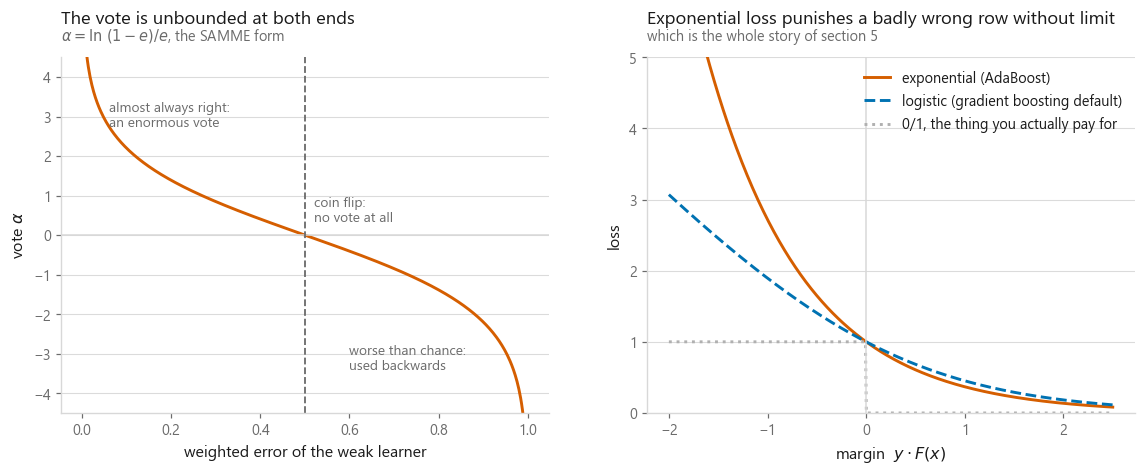

In [2]:
error_rate = np.linspace(0.002, 0.998, 500)
samme_alpha = np.log((1 - error_rate) / error_rate)

margin = np.linspace(-2.0, 2.5, 500)

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.2))

axes[0].plot(error_rate, samme_alpha, color=style.HIGHLIGHT)
axes[0].axhline(0, color=style.RULE, lw=1)
axes[0].axvline(0.5, color=style.MUTED, ls="--", lw=1.2)
axes[0].set_ylim(-4.5, 4.5)
axes[0].set_xlabel("weighted error of the weak learner")
axes[0].set_ylabel(r"vote $\alpha$")
axes[0].annotate("almost always right:\nan enormous vote", xy=(0.06, 2.75),
                 fontsize=9, color=style.MUTED)
axes[0].annotate("coin flip:\nno vote at all", xy=(0.52, 0.35),
                 fontsize=9, color=style.MUTED)
axes[0].annotate("worse than chance:\nused backwards", xy=(0.60, -3.4),
                 fontsize=9, color=style.MUTED)
style.title(axes[0], "The vote is unbounded at both ends",
            r"$\alpha = \ln\,(1-e)/e$, the SAMME form")

axes[1].plot(margin, np.exp(-margin), color=style.HIGHLIGHT,
             label="exponential (AdaBoost)")
axes[1].plot(margin, np.log2(1 + np.exp(-margin)), color=style.PALETTE[0], ls="--",
             label="logistic (gradient boosting default)")
axes[1].plot(margin, (margin <= 0).astype(float), color=style.NEUTRAL, ls=":",
             label="0/1, the thing you actually pay for")
axes[1].axvline(0, color=style.RULE, lw=1)
axes[1].set_ylim(0, 5)
axes[1].set_xlabel(r"margin  $y \cdot F(x)$")
axes[1].set_ylabel("loss")
axes[1].legend(loc="upper right")
style.title(axes[1], "Exponential loss punishes a badly wrong row without limit",
            "which is the whole story of section 5")

style.save(fig, FIG / "fig-01-alpha-and-loss.png")

for e in [0.05, 0.20, 0.40, 0.49, 0.50, 0.60]:
    a = np.log((1 - e) / e)
    print(f"weighted error {e:.2f} -> alpha {a:+.3f}   "
          f"(wrong rows get {np.exp(a):.2f}x heavier)")

The right panel is worth a second look before section 5. All three curves
penalise a negative margin, but the exponential one keeps climbing at a rate
proportional to itself. A row sitting at a margin of $-4$ costs about $e^{4}$,
and the weight it carries into the next round is proportional to that cost. If
that row is impossible to get right, nothing stops the climb.

## 3. From scratch on stumps

A **decision stump** is a tree of depth one: pick a feature, pick a threshold,
predict one class on each side. It is the classic weak learner for AdaBoost and
section 4 explains why.

The nice thing about stumps is that the entire hypothesis space is a short list.
Feature $j$, threshold $t$, and which side gets called $+1$. That list does not
change when the weights change, so I build it once as a matrix and every round is
then a single matrix-vector product.

In [3]:
def stump_grid(X, n_cuts=32):
    """Every candidate stump, precomputed once as a matrix of +1/-1 sides.

    Thresholds are quantiles rather than midpoints between every pair of sorted
    values. That is an approximation, and section 3.3 measures what it costs.
    """
    feats, thresholds = [], []
    quantiles = np.linspace(0.02, 0.98, n_cuts)
    for j in range(X.shape[1]):
        for t in np.unique(np.quantile(X[:, j], quantiles)):
            feats.append(j)
            thresholds.append(t)
    feats = np.asarray(feats)
    thresholds = np.asarray(thresholds)
    side = np.where(X[:, feats] > thresholds, 1.0, -1.0)   # (rows, candidates)
    return feats, thresholds, side


def adaboost_samme(X, y, rounds=200, n_cuts=32, grid=None):
    """AdaBoost.SAMME on stumps. `y` must already be -1 / +1."""
    feats, thresholds, side = grid if grid is not None else stump_grid(X, n_cuts)

    # agree[i, k] = +1 when the rule "call the right-hand side +1" is correct on row i
    agree = side * y[:, None]

    n = len(y)
    w = np.full(n, 1.0 / n)
    n_classes = 2
    picks, alphas, errors, history = [], [], [], [w.copy()]

    for _ in range(rounds):
        # w @ agree is (weight on correct) - (weight on wrong), i.e. 1 - 2 * error,
        # for every candidate at once. One matvec replaces the search.
        score = w @ agree
        k = int(np.argmax(np.abs(score)))       # abs, because any stump can be flipped
        polarity = 1.0 if score[k] > 0 else -1.0
        err = 0.5 * (1.0 - abs(score[k]))

        if err < 1e-10 or err > 0.5 - 1e-10:
            break                                # perfect, or carrying no information

        alpha = np.log((1 - err) / err) + np.log(n_classes - 1)
        wrong = (polarity * side[:, k]) != y
        w = w * np.exp(alpha * wrong)
        w = w / w.sum()

        picks.append((int(feats[k]), float(thresholds[k]), polarity))
        alphas.append(alpha)
        errors.append(err)
        history.append(w.copy())

    return {"picks": picks, "alphas": np.array(alphas),
            "errors": np.array(errors), "weights": np.array(history)}


def decide(X, model):
    """The ensemble score F(x). Its sign is the prediction."""
    F = np.zeros(len(X))
    for (j, t, p), a in zip(model["picks"], model["alphas"]):
        F += a * p * np.where(X[:, j] > t, 1.0, -1.0)
    return F


def staged(X, model):
    """F(x) after every round, for error-against-rounds curves."""
    F = np.zeros(len(X))
    out = []
    for (j, t, p), a in zip(model["picks"], model["alphas"]):
        F = F + a * p * np.where(X[:, j] > t, 1.0, -1.0)
        out.append(F.copy())
    return np.array(out)


print("stump_grid, adaboost_samme, decide, staged: 60 lines and the whole method")

stump_grid, adaboost_samme, decide, staged: 60 lines and the whole method


### 3.1 Watching the weights move

Two interleaving crescents make the mechanics visible. No single axis-aligned cut
separates them, so every stump is badly wrong somewhere, and I can watch which
rows swell.

weights after round 1: min 0.00385  max 0.01667  (uniform was 0.00625)
weights at the end   : min 0.00002  max 0.05260
heaviest row at the end is 8.4x the uniform weight


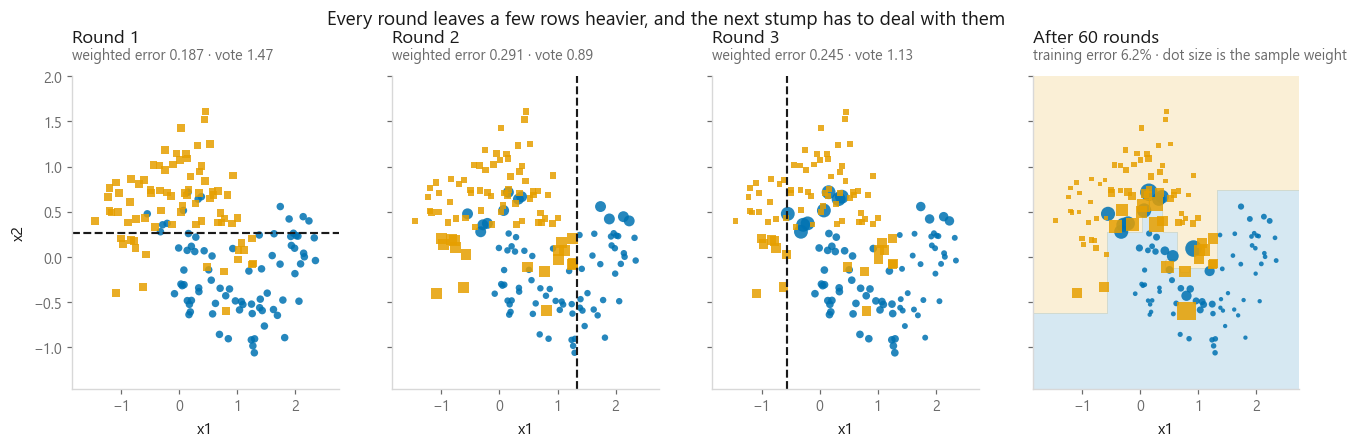

In [4]:
from sklearn.datasets import make_moons

X_toy, y_toy_raw = make_moons(n_samples=160, noise=0.28, random_state=SEED)
y_toy = np.where(y_toy_raw == 1, 1, -1)

toy = adaboost_samme(X_toy, y_toy, rounds=60, n_cuts=40)

fig, axes = plt.subplots(1, 4, figsize=(14.4, 3.7), sharex=True, sharey=True)


def draw_points(ax, weights):
    sizes = 8 + 2600 * weights
    for cls, colour, marker in [(1, style.PALETTE[0], "o"), (-1, style.PALETTE[1], "s")]:
        keep = y_toy == cls
        ax.scatter(X_toy[keep, 0], X_toy[keep, 1], s=sizes[keep], c=colour,
                   marker=marker, alpha=0.85, linewidths=0)


for r in range(3):
    draw_points(axes[r], toy["weights"][r])     # weights going *into* round r + 1
    j, t, _ = toy["picks"][r]
    if j == 0:
        axes[r].axvline(t, color=style.INK, ls="--", lw=1.4)
    else:
        axes[r].axhline(t, color=style.INK, ls="--", lw=1.4)
    style.title(axes[r], f"Round {r + 1}",
                f"weighted error {toy['errors'][r]:.3f} · vote {toy['alphas'][r]:.2f}")

gx, gy = np.meshgrid(np.linspace(X_toy[:, 0].min() - 0.4, X_toy[:, 0].max() + 0.4, 240),
                     np.linspace(X_toy[:, 1].min() - 0.4, X_toy[:, 1].max() + 0.4, 240))
region = np.sign(decide(np.c_[gx.ravel(), gy.ravel()], toy)).reshape(gx.shape)
axes[3].contourf(gx, gy, region, levels=[-2, 0, 2],
                 colors=[style.PALETTE[1], style.PALETTE[0]], alpha=0.16)
draw_points(axes[3], toy["weights"][-1])
toy_err = (np.sign(decide(X_toy, toy)) != y_toy).mean()
style.title(axes[3], f"After {len(toy['alphas'])} rounds",
            f"training error {toy_err:.1%} · dot size is the sample weight")

for ax in axes:
    ax.set_xlabel("x1")
    ax.grid(visible=False)
axes[0].set_ylabel("x2")
fig.suptitle("Every round leaves a few rows heavier, and the next stump has to deal with them",
             x=0.5, y=1.04, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-02-rounds-on-moons.png")

print(f"weights after round 1: min {toy['weights'][1].min():.5f}  "
      f"max {toy['weights'][1].max():.5f}  (uniform was {1/len(y_toy):.5f})")
print(f"weights at the end   : min {toy['weights'][-1].min():.5f}  "
      f"max {toy['weights'][-1].max():.5f}")
print(f"heaviest row at the end is {toy['weights'][-1].max() * len(y_toy):.1f}x the uniform weight")

Each dashed line is one stump, which on its own is a terrible classifier. The
dots grow where the stumps keep failing, which is along the seam where the two
crescents interlock, and the last panel shows what sixty of these votes build:
a boundary no single stump could express.

### 3.2 On real data

The Dry Bean set has seven varieties. I take the two largest, which gives a
binary problem with heavy overlap, and hold out a third of it.

In [5]:
from sklearn.model_selection import train_test_split

X_all, y_all = datasets.dry_bean()
feature_names = X_all.columns.tolist()

pair = y_all.value_counts().index[:2].tolist()
keep = y_all.isin(pair).to_numpy()
X_pair = X_all.to_numpy(dtype=float)[keep]
y_pair = np.where(y_all.to_numpy()[keep] == pair[0], 1, -1)

X_train, X_test, y_train, y_test = train_test_split(
    X_pair, y_pair, test_size=0.3, stratify=y_pair, random_state=SEED)

print(f"classes: +1 = {pair[0]}, -1 = {pair[1]}")
print(f"train {X_train.shape[0]:,} rows, test {X_test.shape[0]:,} rows, "
      f"{X_train.shape[1]} features")
print(f"majority class baseline on the test set: {max((y_test == 1).mean(), (y_test == -1).mean()):.4f}")

classes: +1 = DERMASON, -1 = SIRA
train 4,327 rows, test 1,855 rows, 16 features
majority class baseline on the test set: 0.5736


In [6]:
ROUNDS = 200

grid = stump_grid(X_train, n_cuts=32)
mine = adaboost_samme(X_train, y_train, rounds=ROUNDS, grid=grid)

first_rounds = pd.DataFrame({
    "round": np.arange(1, 9),
    "feature": [feature_names[j] for j, _, _ in mine["picks"][:8]],
    "threshold": [f"{t:,.2f}" for _, t, _ in mine["picks"][:8]],
    "calls +1": ["above" if p > 0 else "below" for _, _, p in mine["picks"][:8]],
    "weighted error": [f"{e:.4f}" for e in mine["errors"][:8]],
    "alpha": [f"{a:.4f}" for a in mine["alphas"][:8]],
})
print(f"{len(mine['alphas'])} stumps out of {ROUNDS} rounds requested\n")
print(first_rounds.to_string(index=False))

200 stumps out of 200 rounds requested

 round      feature threshold calls +1 weighted error  alpha
     1    Perimeter    749.00    below         0.0823 2.4118
     2    Perimeter    699.57    below         0.2445 1.1280
     3         Area 42,240.69    below         0.2981 0.8564
     4    Perimeter    749.00    above         0.3306 0.7057
     5         Area 33,097.29    below         0.3487 0.6248
     6   ConvexArea 42,760.13    below         0.3155 0.7745
     7         Area 32,191.80    below         0.3737 0.5164
     8 ShapeFactor4      1.00    above         0.3850 0.4683


Round one picks the single best split in the dataset. Every round after it picks
the best split *for the current weights*, which is why the same feature comes
back with different thresholds: once the easy side of a cut is settled, the
weights move and a different part of the same axis becomes worth cutting.

Watch the weighted error column. It climbs toward 0.5 and stays there. That is
not a failure — it is the algorithm working. Each round pushes the weights until
the previous stump would be a coin flip on them, so the next stump is forced to
find something genuinely new.

### 3.3 Checked against scikit-learn

In [7]:
from sklearn.ensemble import AdaBoostClassifier

sk = AdaBoostClassifier(n_estimators=ROUNDS, random_state=SEED).fit(X_train, y_train)

mine_test = np.sign(decide(X_test, mine))
sk_test = sk.predict(X_test)

print(f"my accuracy      : {(mine_test == y_test).mean():.4f}")
print(f"sklearn accuracy : {sk.score(X_test, y_test):.4f}")
print(f"the two agree on : {(mine_test == sk_test).mean():.4%} of test rows")
print(f"stumps used      : mine {len(mine['alphas'])}, sklearn {len(sk.estimators_)}")

train_curve = (np.sign(staged(X_train, mine)) != y_train).mean(axis=1)
test_curve = (np.sign(staged(X_test, mine)) != y_test).mean(axis=1)
print(f"\ntraining error after 1 round  : {train_curve[0]:.4f}")
print(f"training error after {len(train_curve)} rounds: {train_curve[-1]:.4f}")
print(f"test error after {len(test_curve)} rounds    : {test_curve[-1]:.4f}")

my accuracy      : 0.9208
sklearn accuracy : 0.9137
the two agree on : 97.6819% of test rows
stumps used      : mine 200, sklearn 200

training error after 1 round  : 0.0823
training error after 200 rounds: 0.0666
test error after 200 rounds    : 0.0792


Close, but not identical, and the reason is worth knowing. My stumps search a
grid of quantile thresholds, while scikit-learn's `DecisionTreeClassifier`
searches every split point and scores it with weighted Gini rather than weighted
error directly. Two slightly different stumps at round one send the weights down
two slightly different paths, and the paths never reconverge. The ensembles still
end up in the same place, which is the point of the check.

### 3.4 The gradient view, run side by side

Section 2 claimed that reweighting rows and fitting the residual are the same
operation. Here is the second loop. It never mentions a sample weight. It
computes the negative gradient of the exponential loss, finds the stump most
correlated with it, and picks a step size by exact line search — the standard
gradient boosting recipe.

In [8]:
def gradient_view(X, y, rounds, grid):
    """Gradient boosting on the exponential loss. Same stumps, different vocabulary."""
    feats, thresholds, side = grid
    F = np.zeros(len(y))
    picks, steps = [], []

    for _ in range(rounds):
        room = -y * F
        # subtracting the max keeps exp() from overflowing; only ratios are used
        cost = np.exp(room - room.max())
        gradient = y * cost                       # -dL/dF, the target to chase

        corr = gradient @ side
        k = int(np.argmax(np.abs(corr)))
        polarity = 1.0 if corr[k] > 0 else -1.0
        h = polarity * side[:, k]

        right = cost[h == y].sum()
        wrong = cost[h != y].sum()
        if wrong <= 0:
            break
        step = 0.5 * np.log(right / wrong)        # exact line search, not a guess

        F = F + step * h
        picks.append((int(feats[k]), float(thresholds[k]), polarity))
        steps.append(step)

    return picks, np.array(steps), F


g_picks, g_steps, g_F = gradient_view(X_train, y_train, len(mine["alphas"]), grid)

same = sum(a == b for a, b in zip(mine["picks"], g_picks))
print(f"rounds where both loops chose the same stump: {same} / {len(g_picks)}")
print(f"largest gap between AdaBoost's alpha and twice the gradient step: "
      f"{np.abs(mine['alphas'] - 2 * g_steps).max():.2e}")
print(f"largest gap between the two ensemble scores F, after doubling: "
      f"{np.abs(decide(X_train, mine) - 2 * g_F).max():.2e}")
print("\nAdaBoost is gradient boosting with exponential loss. Same rounds, same answer.")

rounds where both loops chose the same stump: 200 / 200
largest gap between AdaBoost's alpha and twice the gradient step: 4.00e-14
largest gap between the two ensemble scores F, after doubling: 5.24e-14

AdaBoost is gradient boosting with exponential loss. Same rounds, same answer.


### 3.5 Where the weight ends up

The weight vector is the interesting object in AdaBoost, so I saved all of it.
Two views: what happens to individual rows, and how concentrated the total gets.

heaviest training row ends at 31x the uniform weight
the heaviest 1% of rows hold 15.5% of the weight
the lightest half of rows hold 0.76% of the weight


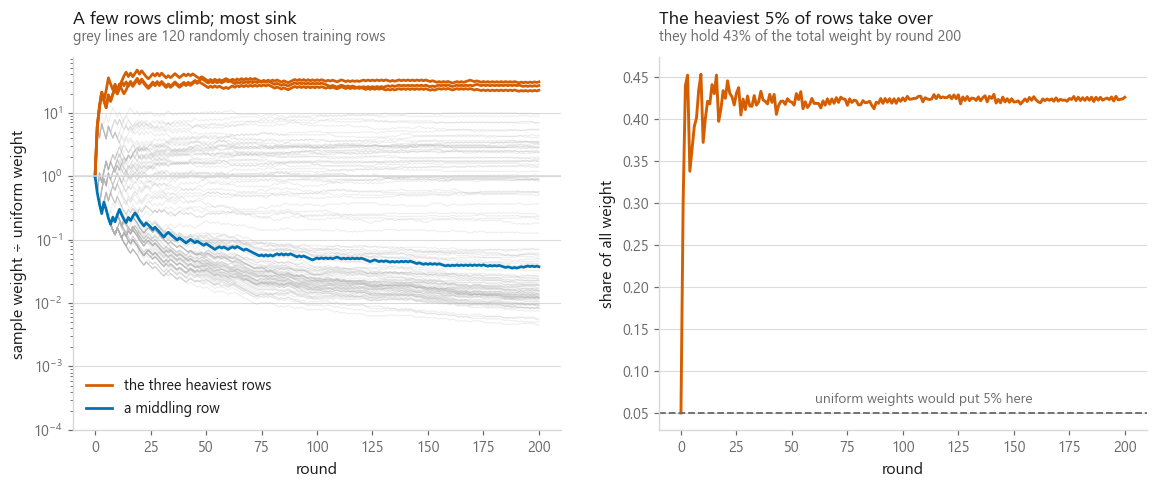

In [9]:
W = mine["weights"] * len(y_train)          # 1.0 means "still at the uniform weight"
n_rounds_kept = W.shape[0]
rounds_axis = np.arange(n_rounds_kept)
final_rank = np.argsort(W[-1])

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))

rng = np.random.default_rng(SEED)
for i in rng.choice(len(y_train), 120, replace=False):
    axes[0].plot(rounds_axis, np.clip(W[:, i], 1e-4, None), color=style.NEUTRAL,
                 alpha=0.22, lw=0.7)
for rank, i in enumerate(final_rank[-3:]):
    axes[0].plot(rounds_axis, W[:, i], color=style.HIGHLIGHT, lw=1.8,
                 label="the three heaviest rows" if rank == 0 else None)
mid = final_rank[len(final_rank) // 2]
axes[0].plot(rounds_axis, np.clip(W[:, mid], 1e-4, None), color=style.PALETTE[0],
             lw=1.8, label="a middling row")
axes[0].axhline(1.0, color=style.RULE, lw=1)
axes[0].set_yscale("log")
axes[0].set_ylim(1e-4, None)
axes[0].set_xlabel("round")
axes[0].set_ylabel("sample weight ÷ uniform weight")
axes[0].legend(loc="lower left")
style.title(axes[0], "A few rows climb; most sink",
            "grey lines are 120 randomly chosen training rows")

top = max(1, int(0.05 * len(y_train)))
share = np.sort(W, axis=1)[:, -top:].sum(axis=1) / len(y_train)
axes[1].plot(rounds_axis, share, color=style.HIGHLIGHT)
axes[1].axhline(0.05, color=style.MUTED, ls="--", lw=1.2)
axes[1].annotate("uniform weights would put 5% here", xy=(n_rounds_kept * 0.3, 0.062),
                 fontsize=9, color=style.MUTED)
axes[1].set_xlabel("round")
axes[1].set_ylabel("share of all weight")
style.title(axes[1], "The heaviest 5% of rows take over",
            f"they hold {share[-1]:.0%} of the total weight by round {n_rounds_kept - 1}")

style.save(fig, FIG / "fig-03-weights-concentrate.png")

print(f"heaviest training row ends at {W[-1].max():,.0f}x the uniform weight")
print(f"the heaviest 1% of rows hold {np.sort(W[-1])[-max(1, len(y_train)//100):].sum() / len(y_train):.1%} "
      f"of the weight")
print(f"the lightest half of rows hold {np.sort(W[-1])[:len(y_train)//2].sum() / len(y_train):.2%} "
      f"of the weight")

The left panel is the mechanism in one picture. Most rows sink out of the bottom
of the chart: they are settled, and no later stump is paid anything for getting
them right. A handful climb by orders of magnitude, and those are the rows that
decide what every remaining stump looks like.

This is a feature while the hard rows are genuinely hard. Section 5 is about what
happens when a hard row is hard because somebody typed the label wrong.

## 4. Weak learners, and what happens if they are too strong

The received wisdom is that AdaBoost wants stumps. The reason follows from
section 2: $\alpha$ depends on the weighted error, and if a base learner drives
that error to zero on round one, then $\alpha \to \infty$ and the whole ensemble
is one tree. Boosting only has room to work if each learner leaves work behind.

I take that literally and boost trees of depth 1, 2, 3, and unlimited.

base learner       trees used  round-1 error  round-1 alpha  train acc  test acc
stump (depth 1)           200         0.0800         2.4428     0.9344    0.9137
depth 2                   200         0.0800         2.4428     0.9411    0.9186
depth 3                   200         0.0779         2.4715     0.9813    0.9132
unlimited                   1         0.0000         1.0000     1.0000    0.8922


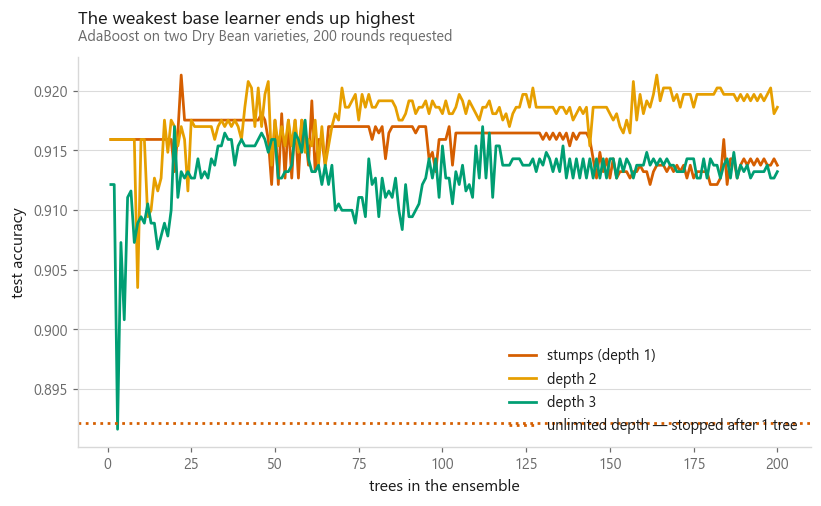

In [10]:
from sklearn.tree import DecisionTreeClassifier

depths = [1, 2, 3, None]
runs = {}
for d in depths:
    model = AdaBoostClassifier(
        DecisionTreeClassifier(max_depth=d, random_state=SEED),
        n_estimators=ROUNDS, random_state=SEED).fit(X_train, y_train)
    runs[d] = {
        "model": model,
        "test_curve": np.array(list(model.staged_score(X_test, y_test))),
        "train_acc": model.score(X_train, y_train),
        "n_used": len(model.estimators_),
        "first_error": model.estimator_errors_[0],
        "first_alpha": model.estimator_weights_[0],
    }

fig, ax = plt.subplots(figsize=(8.6, 4.6))
for i, d in enumerate(depths):
    name = "stumps (depth 1)" if d == 1 else f"depth {d}" if d else "unlimited depth"
    colour = style.HIGHLIGHT if d == 1 else style.PALETTE[i]
    curve = runs[d]["test_curve"]
    if len(curve) == 1:
        ax.axhline(curve[0], color=colour, ls=":", lw=1.8,
                   label=f"{name} — stopped after {len(curve)} tree")
    else:
        ax.plot(np.arange(1, len(curve) + 1), curve, color=colour, lw=1.8, label=name)
ax.set_xlabel("trees in the ensemble")
ax.set_ylabel("test accuracy")
ax.legend(loc="lower right")
style.title(ax, "The weakest base learner ends up highest",
            "AdaBoost on two Dry Bean varieties, 200 rounds requested")
style.save(fig, FIG / "fig-04-how-weak.png")

print(f"{'base learner':<18}{'trees used':>11}{'round-1 error':>15}{'round-1 alpha':>15}"
      f"{'train acc':>11}{'test acc':>10}")
for d in depths:
    r = runs[d]
    name = "stump (depth 1)" if d == 1 else f"depth {d}" if d else "unlimited"
    print(f"{name:<18}{r['n_used']:>11}{r['first_error']:>15.4f}{r['first_alpha']:>15.4f}"
          f"{r['train_acc']:>11.4f}{r['test_curve'][-1]:>10.4f}")

An unlimited-depth tree memorises the training set, so its weighted error is zero,
its $\alpha$ is undefined, and scikit-learn does the only sensible thing: it stops.
The ensemble is a single overfitted tree wearing an ensemble's name. Depth 3 is
not that bad, but each tree still eats most of the signal, its $\alpha$ is large,
and the later trees have little left to correct.

Stumps are slow, and that is the point. Each one contributes a little, its
$\alpha$ stays small, and two hundred small corrections shape a boundary that no
member of the ensemble could describe. The trade is compute: to get the same
accuracy you fit many more models.

One consequence people forget. **An ensemble of stumps is an additive model.**
Each stump touches exactly one feature, so the total is a sum of one-dimensional
step functions with no interaction terms anywhere. If the truth needs "feature A
matters only when feature B is high", stumps cannot say it however many rounds
you run, and depth 2 becomes the honest choice.

## 5. Label noise, the known weakness

Now the failure. Look again at the exponential curve in figure 1 and at the weight
trajectories in figure 3, and the problem writes itself.

A mislabelled row is a row no weak learner can get right, because getting it right
means being wrong about the pattern. Its margin goes more negative every round.
Its weight is the exponential of that margin. So it grows without limit, and once
a handful of impossible rows carry most of the weight, every later stump is fitted
to explain them, and every later stump is therefore worse.

Bagging has no such loop. A wrong label sits in about 63% of the bootstrap
samples, damages the trees that saw it, and is outvoted by the rest. Nothing about
it gets amplified.

I flip a percentage of **training** labels, leave the test labels clean, and give
AdaBoost and a random forest the same budget of 300 trees.

In [11]:
from sklearn.ensemble import RandomForestClassifier

noise_levels = [0.0, 0.03, 0.06, 0.10, 0.15, 0.20, 0.30]
repeats = 3
N_TREES = 300

results = {"AdaBoost (300 stumps)": [], "random forest (300 trees)": []}


def flip_labels(y, rate, seed):
    """Flip `rate` of the labels at random. y is -1/+1, so a flip is a negation."""
    rng = np.random.default_rng(seed)
    noisy = y.copy()
    idx = rng.choice(len(y), int(round(rate * len(y))), replace=False)
    noisy[idx] = -noisy[idx]
    return noisy


for rate in noise_levels:
    ada_scores, rf_scores = [], []
    for rep in range(repeats):
        y_noisy = flip_labels(y_train, rate, seed=1000 * rep + int(rate * 100))
        ada = AdaBoostClassifier(n_estimators=N_TREES, random_state=SEED)
        rf = RandomForestClassifier(n_estimators=N_TREES, n_jobs=-1, random_state=SEED)
        ada_scores.append(ada.fit(X_train, y_noisy).score(X_test, y_test))
        rf_scores.append(rf.fit(X_train, y_noisy).score(X_test, y_test))
    results["AdaBoost (300 stumps)"].append(np.mean(ada_scores))
    results["random forest (300 trees)"].append(np.mean(rf_scores))
    print(f"{rate:>5.0%} of labels flipped -> AdaBoost {np.mean(ada_scores):.4f}   "
          f"forest {np.mean(rf_scores):.4f}")

   0% of labels flipped -> AdaBoost 0.9148   forest 0.9164


   3% of labels flipped -> AdaBoost 0.9155   forest 0.9182


   6% of labels flipped -> AdaBoost 0.9143   forest 0.9163


  10% of labels flipped -> AdaBoost 0.9145   forest 0.9152


  15% of labels flipped -> AdaBoost 0.9146   forest 0.9166


  20% of labels flipped -> AdaBoost 0.9155   forest 0.9044


  30% of labels flipped -> AdaBoost 0.9094   forest 0.8413


flipped rows are 10.0% of the training set
by the last round they hold 35.7% of the weight
average weight of a flipped row is 5x that of a clean row

accuracy lost from clean to 30% noise:
  AdaBoost (300 stumps)       +0.0054
  random forest (300 trees)   +0.0751


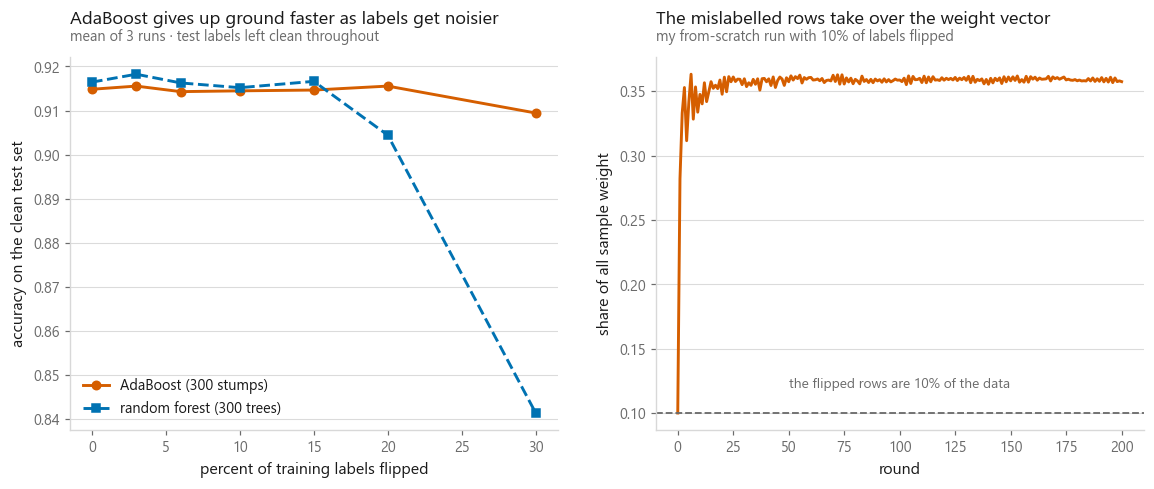

In [12]:
# The mechanism, measured: how much of the weight ends up on the flipped rows?
NOISE_SHOWN = 0.10
y_noisy = flip_labels(y_train, NOISE_SHOWN, seed=SEED)
noisy_run = adaboost_samme(X_train, y_noisy, rounds=ROUNDS, grid=grid)
bad = y_noisy != y_train
bad_share = noisy_run["weights"][:, bad].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))

levels_pct = [r * 100 for r in noise_levels]
for i, (name, curve) in enumerate(results.items()):
    colour = style.HIGHLIGHT if i == 0 else style.PALETTE[0]
    axes[0].plot(levels_pct, curve, marker=style.MARKERS[i], color=colour,
                 ls=["-", "--"][i], label=name)
axes[0].set_xlabel("percent of training labels flipped")
axes[0].set_ylabel("accuracy on the clean test set")
axes[0].legend(loc="lower left")
style.title(axes[0], "AdaBoost gives up ground faster as labels get noisier",
            f"mean of {repeats} runs · test labels left clean throughout")

axes[1].plot(np.arange(len(bad_share)), bad_share, color=style.HIGHLIGHT)
axes[1].axhline(bad.mean(), color=style.MUTED, ls="--", lw=1.2)
axes[1].annotate(f"the flipped rows are {bad.mean():.0%} of the data",
                 xy=(len(bad_share) * 0.25, bad.mean() + 0.02),
                 fontsize=9, color=style.MUTED)
axes[1].set_xlabel("round")
axes[1].set_ylabel("share of all sample weight")
style.title(axes[1], "The mislabelled rows take over the weight vector",
            f"my from-scratch run with {NOISE_SHOWN:.0%} of labels flipped")

style.save(fig, FIG / "fig-05-label-noise.png")

clean_mean = noisy_run["weights"][-1][~bad].mean()
bad_mean = noisy_run["weights"][-1][bad].mean()
print(f"flipped rows are {bad.mean():.1%} of the training set")
print(f"by the last round they hold {bad_share[-1]:.1%} of the weight")
print(f"average weight of a flipped row is {bad_mean / clean_mean:,.0f}x that of a clean row")
print(f"\naccuracy lost from clean to {noise_levels[-1]:.0%} noise:")
for name, curve in results.items():
    print(f"  {name:<28}{curve[0] - curve[-1]:+.4f}")

The right panel is the failure in one line. The flipped rows are a tenth of the
training set and they end up holding a large majority of the weight, so most of
the later stumps are fitted almost entirely to rows whose labels are wrong.

The left panel is what that costs. Both models start close and both decline, but
the forest declines more gently, because a wrong label there is one vote among
hundreds instead of a growing obsession.

### What to do about it

There is no switch that fixes this, but there are choices that reduce it.

| | |
|---|---|
| **Fewer rounds** | The damage accumulates, so early stopping on a validation set genuinely helps. Check where the validation curve turns |
| **A smaller learning rate** | `learning_rate` scales every $\alpha$, which slows the growth of the weights along with everything else |
| **A different loss** | Logistic loss grows linearly in the margin instead of exponentially, so a hopeless row plateaus. That is [gradient boosting](../05-gradient-boosting/) with the default loss, and it is the usual answer |
| **Clean the labels** | Rows that AdaBoost pushes to the top of the weight ranking are worth reading by hand. The weakness doubles as a label-error detector |

The last one is not a joke. The weight vector is a ranked list of rows your model
finds impossible, and in tabular data those are often exactly the rows that were
entered wrong.

## Cheat sheet

| | |
|---|---|
| **What it does** | Fits weak models in sequence, reweighting the rows each one gets wrong, then takes a weighted vote |
| **Loss** | Exponential, $\sum_i \exp(-y_i F(x_i))$. This single choice explains everything else |
| **The vote** | $\alpha = \ln\frac{1-e}{e}$ for two classes. Zero at chance, negative below it, unbounded above |
| **Base learner** | Depth 1 is the default and the right starting point. Depth 2 or 3 if the problem needs feature interactions. Never unpruned |
| **Mainly reduces** | Bias. It is the opposite tool to [bagging](../01-bagging/), which reduces variance |
| **Can it overfit** | Yes, unlike a [random forest](../02-random-forest/). Rounds are a hyperparameter, not a "more is better" dial |
| **Weakness** | Label noise and outliers. Weight on an impossible row grows exponentially and never comes back |
| **Relation to boosting proper** | It *is* gradient boosting, with exponential loss and an exact line search |
| **Multiclass** | SAMME adds $\ln(K-1)$ to $\alpha$; scikit-learn does this for you |
| **Next** | [Gradient boosting](../05-gradient-boosting/), which swaps the loss for one you choose and fixes most of section 5 |

## What to remember

1. Bagging is parallel and cancels variance. AdaBoost is sequential and cuts bias.
   They want opposite base learners: bagging wants them too strong, boosting wants
   them too weak.
2. The sample weights are not a heuristic. They are what is left of the
   exponential loss after the frozen part of the ensemble is factored out.
3. $\alpha = \frac{1}{2}\ln\frac{1-e}{e}$ falls out of one derivative. It is zero
   at a coin flip and negative for a learner that is worse than chance.
4. Reweighting rows and fitting residuals are the same operation. AdaBoost is
   gradient boosting with exponential loss, and section 3.4 checks it round by round.
5. Boost something strong enough to fit the training set and the ensemble collapses
   to one model.
6. A wrong label is a row that can never be fixed, so its weight grows without
   limit. That is why AdaBoost loses to a forest as noise rises, and why the
   heaviest rows are worth inspecting by hand.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [04-05 Gradient boosting](../05-gradient-boosting/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#AdaBoost` `#Boosting` `#Ensemble` `#DecisionStumps`
`#GradientBoosting` `#Python` `#ScikitLearn` `#DataScience` `#MLTutorial`